Paso 1: Preparación del Entorno Analítico
- Descripción: "Cargamos las herramientas de procesamiento y visualización de datos. Este stack nos permitirá realizar la limpieza y auditoría técnica de los registros de facturación."

In [3]:
# Importación de librerías para manipulación y graficación
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de salida para visualizaciones
%matplotlib inline

Paso 2: Ingesta de Facturas de Compra
- Descripción: "Importamos el set de datos de facturas (Invoices) correspondiente al cierre de 2016. Esta tabla es fundamental para conciliar los pagos a proveedores y los montos totales de adquisición."

In [4]:
# Lectura de la fuente de datos original
df_facturas = pd.read_csv("../data/InvoicePurchases12312016.csv", sep=',')

Paso 3: Diagnóstico Estructural y de Metadatos
- Descripción: "Evaluamos el volumen de facturas recibidas y auditamos los tipos de datos asignados a cada columna. Este paso asegura que los identificadores y montos monetarios sean procesables."

In [5]:
# Inspección de dimensiones y primeras entradas
print(f"Estructura del dataset (Filas, Columnas): {df_facturas.shape}")
display(df_facturas.head())

# Validación de la naturaleza técnica de las variables
print("\nResumen de tipos de datos:")
print(df_facturas.dtypes)

Estructura del dataset (Filas, Columnas): (5543, 10)


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2016-01-04,8124,2015-12-21,2016-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2016-01-07,8137,2015-12-22,2016-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2016-01-09,8169,2015-12-24,2016-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2016-01-12,8106,2015-12-20,2016-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2016-01-07,8170,2015-12-24,2016-02-12,1935,15527.25,429.20,NaN



Resumen de tipos de datos:
VendorNumber      int64
VendorName          str
InvoiceDate         str
PONumber          int64
PODate              str
PayDate             str
Quantity          int64
Dollars         float64
Freight         float64
Approval            str
dtype: object


Paso 4: Auditoría de Integridad (Nulos y Vacíos)
- Descripción: "Escaneamos el dataset en busca de campos vacíos. Identificar celdas nulas en una tabla de facturación es crítico, ya que podría indicar errores en las fechas de cobro o en los montos de impuestos."

In [6]:
# Cuantificación de valores nulos por variable
ausencia_datos = df_facturas.isna().sum()
print("Conteo de nulos por columna:")
print(ausencia_datos)

# Aislamiento de registros incompletos para inspección
filas_incompletas = df_facturas[df_facturas.isnull().any(axis=1)]

if not filas_incompletas.empty:
    print("\nRegistros con valores faltantes localizados:")
    display(filas_incompletas)
else:
    print("\nValidación exitosa: No se encontraron registros nulos.")

Conteo de nulos por columna:
VendorNumber       0
VendorName         0
InvoiceDate        0
PONumber           0
PODate             0
PayDate            0
Quantity           0
Dollars            0
Freight            0
Approval        5169
dtype: int64

Registros con valores faltantes localizados:


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2016-01-04,8124,2015-12-21,2016-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2016-01-07,8137,2015-12-22,2016-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2016-01-09,8169,2015-12-24,2016-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2016-01-12,8106,2015-12-20,2016-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2016-01-07,8170,2015-12-24,2016-02-12,1935,15527.25,429.20,NaN
...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2017-01-06,13626,2016-12-21,2017-02-10,90,1563.00,8.60,NaN
5539,9625,WESTERN SPIRITS BEVERAGE CO,2017-01-10,13661,2016-12-23,2017-02-18,4617,37300.48,186.50,NaN
5540,3664,WILLIAM GRANT & SONS INC,2017-01-02,13643,2016-12-22,2017-02-04,9848,202815.78,932.95,NaN
5541,9815,WINE GROUP INC,2017-01-03,13602,2016-12-20,2017-02-08,24747,149007.56,819.54,NaN


Paso 5: Control de Redundancia y Duplicidad
- Descripción: "Buscamos registros idénticos que pudieran duplicar la deuda con proveedores. Aseguramos que cada factura sea única para mantener la salud financiera del análisis."

In [7]:
# Verificación de duplicados totales
total_redundantes = df_facturas.duplicated().sum()

print(f"Total de registros duplicados detectados: {total_redundantes}")

# Detalle de duplicados si existen
if total_redundantes > 0:
    print("Registros repetidos encontrados:")
    display(df_facturas[df_facturas.duplicated()])

Total de registros duplicados detectados: 0


Paso 6: Validación de Signos en Valores Numéricos
- Descripción: "Realizamos un barrido de integridad sobre las columnas cuantitativas para detectar valores negativos. En facturación, montos negativos podrían representar errores de carga o notas de crédito que deben ser analizadas."

In [8]:
# Identificación de valores inferiores a cero en variables numéricas
df_subset_num = df_facturas.select_dtypes(include=[np.number])
deteccion_negativos = (df_subset_num < 0).any()

# Extracción de variables con anomalías de signo
lista_negativos = deteccion_negativos[deteccion_negativos].index.tolist()

if lista_negativos:
    print(f"Alerta: Se detectaron valores negativos en: {lista_negativos}")
    for col_neg in lista_negativos:
        print(f"\nRegistros anómalos en la columna '{col_neg}':")
        display(df_facturas[df_facturas[col_neg] < 0])
else:
    print("Validación de integridad completada: No existen valores negativos en el dataset.")

Validación de integridad completada: No existen valores negativos en el dataset.


Paso 7: Imputación de Estados de Aprobación
- Descripción: "Tratamos los valores faltantes en la columna de validación. Al ser una variable categórica, asignamos la etiqueta 'No Aplica' a las celdas vacías para normalizar la columna y permitir un análisis de auditoría sin registros nulos."

In [9]:
# Saneamiento de la variable de aprobación mediante el método fillna
df_facturas['Approval'] = df_facturas['Approval'].fillna('No Aplica')

# Validación inmediata de la integridad del set de datos
print(f"¿Existen nulos residuales?: {df_facturas.isnull().values.any()}")

¿Existen nulos residuales?: False


Paso 8: Normalización y Renombrado de Negocio
- Descripción: "Estandarizamos los encabezados del dataset a una terminología técnica en español. Esta acción alinea la tabla de facturas con el resto de los módulos del proyecto (Ventas y Compras), facilitando su integración."

In [10]:
# Mapeo de traducción para la estructura de facturación
mapeo_columnas = {
    'VendorNumber': 'Proveedor_ID',
    'VendorName': 'Nombre_Proveedor',
    'InvoiceDate': 'Fecha_Compra',
    'PONumber': 'Compra_ID',
    'PODate': 'Fecha_Orden_Compra',
    'PayDate': 'Fecha_Pago',
    'Quantity': 'Cantidad',
    'Dollars': 'Importe',
    'Freight': 'Costo_Envio',
    'Approval': 'Aprobacion'
}

# Ejecución del renombrado de forma persistente
df_facturas.rename(columns=mapeo_columnas, inplace=True)

# Vista previa de la nueva arquitectura de datos
display(df_facturas.head())

,Proveedor_ID,Nombre_Proveedor,Fecha_Compra,Compra_ID,Fecha_Orden_Compra,Fecha_Pago,Cantidad,Importe,Costo_Envio,Aprobacion
0,105,ALTAMAR BRANDS LLC,2016-01-04,8124,2015-12-21,2016-02-16,6,214.26,3.47,No Aplica
1,4466,AMERICAN VINTAGE BEVERAGE,2016-01-07,8137,2015-12-22,2016-02-21,15,140.55,8.57,No Aplica
2,388,ATLANTIC IMPORTING COMPANY,2016-01-09,8169,2015-12-24,2016-02-16,5,106.60,4.61,No Aplica
3,480,BACARDI USA INC,2016-01-12,8106,2015-12-20,2016-02-05,10100,137483.78,2935.20,No Aplica
4,516,BANFI PRODUCTS CORP,2016-01-07,8170,2015-12-24,2016-02-12,1935,15527.25,429.20,No Aplica


Paso 9: Auditoría Descriptiva General (EDA)
- Descripción: "Iniciamos el Análisis Exploratorio mediante un barrido estadístico de todas las dimensiones. Este proceso nos permite comprender la distribución de las facturas, los volúmenes de compra y los costos logísticos asociados."

In [11]:
# Iteración masiva para obtener el perfil estadístico de cada variable
for var in df_facturas.columns:
    print(f"Variable Analizada: {var}")
    print(df_facturas[var].describe())
    print("-" * 35)

Variable Analizada: Proveedor_ID
count      5543.00000
mean      20662.75212
std       34582.15841
min           2.00000
25%        3089.00000
50%        7240.00000
75%       10754.00000
max      201359.00000
Name: Proveedor_ID, dtype: float64
-----------------------------------
Variable Analizada: Nombre_Proveedor
count                            5543
unique                            129
top       AMERICAN VINTAGE BEVERAGE  
freq                               55
Name: Nombre_Proveedor, dtype: object
-----------------------------------
Variable Analizada: Fecha_Compra
count           5543
unique           373
top       2016-07-04
freq              43
Name: Fecha_Compra, dtype: object
-----------------------------------
Variable Analizada: Compra_ID
count     5543.000000
mean     10889.419087
std       1600.859969
min       8106.000000
25%       9503.500000
50%      10890.000000
75%      12275.500000
max      13661.000000
Name: Compra_ID, dtype: float64
--------------------------------

Paso 10: Diagnóstico Detallado de Métricas Cuantitativas
- Descripción: "Desarrollamos una función de auditoría técnica para las variables numéricas. Analizamos la recurrencia de valores, promedios y extremos para asegurar que los flujos de caja y cantidades sean consistentes con la operación."

In [12]:
# Definición de columnas de interés para análisis profundo
# Nota: Ajustado 'ProveedorID' para coincidir con el renombrado previo
metricas_cuantitativas = ['Proveedor_ID', 'Compra_ID', 'Cantidad', 'Importe', 'Costo_Envio']

def auditoria_metadatos_pro(df, col):
    stats = df[col].describe()
    print(f"\n--- Diagnóstico Técnico: '{col}' ---")
    print(f"Total registros: {len(df[col])}")
    print(f"Valores únicos: {df[col].nunique()}")
    print(f"Moda (Top): {df[col].mode()[0]} | Freq: {df[col].value_counts().iloc[0]}")
    print(f"Rango: [{stats['min']} a {stats['max']}]")
    print(f"Media aritmética: {stats['mean']:.2f}")

# Ejecución del diagnóstico por ciclo
for item in metricas_cuantitativas:
    auditoria_metadatos_pro(df_facturas, item)


--- Diagnóstico Técnico: 'Proveedor_ID' ---
Total registros: 5543
Valores únicos: 126
Moda (Top): 4425 | Freq: 82
Rango: [2.0 a 201359.0]
Media aritmética: 20662.75

--- Diagnóstico Técnico: 'Compra_ID' ---
Total registros: 5543
Valores únicos: 5543
Moda (Top): 8106 | Freq: 1
Rango: [8106.0 a 13661.0]
Media aritmética: 10889.42

--- Diagnóstico Técnico: 'Cantidad' ---
Total registros: 5543
Valores únicos: 2895
Moda (Top): 12 | Freq: 228
Rango: [1.0 a 141660.0]
Media aritmética: 6058.88

--- Diagnóstico Técnico: 'Importe' ---
Total registros: 5543
Valores únicos: 5226
Moda (Top): 214.26 | Freq: 22
Rango: [4.14 a 1660435.88]
Media aritmética: 58073.38

--- Diagnóstico Técnico: 'Costo_Envio' ---
Total registros: 5543
Valores únicos: 4052
Moda (Top): 0.26 | Freq: 13
Rango: [0.02 a 8468.22]
Media aritmética: 295.95


Paso 11: Identificación de Costos Logísticos Atípicos
- Descripción: "Exploramos la variable de costos de envío para localizar las transacciones con mayor impacto en el flete. Analizar el Top 40 de facturas con mayor Costo_envio ayuda a detectar envíos especiales o posibles ineficiencias en el transporte."

In [13]:
# Selección de los 40 registros con fletes más elevados
top_costos_logistica = df_facturas.nlargest(40, 'Costo_Envio')

# Visualización del impacto logístico por proveedor
print("Desglose de Facturas con Mayor Costo de Envío:")
display(top_costos_logistica)

Desglose de Facturas con Mayor Costo de Envío:


,Proveedor_ID,Nombre_Proveedor,Fecha_Compra,Compra_ID,Fecha_Orden_Compra,Fecha_Pago,Cantidad,Importe,Costo_Envio,Aprobacion
4728,3960,DIAGEO NORTH AMERICA INC,2016-11-15,12833,2016-10-30,2016-12-19,141660,1660435.88,8468.22,Frank Delahunt
4627,3960,DIAGEO NORTH AMERICA INC,2016-11-12,12771,2016-10-26,2016-12-24,127553,1409683.51,7753.26,Frank Delahunt
2822,3960,DIAGEO NORTH AMERICA INC,2016-07-16,10936,2016-06-27,2016-08-13,131712,1377224.55,7574.74,Frank Delahunt
4521,3960,DIAGEO NORTH AMERICA INC,2016-11-03,12618,2016-10-16,2016-12-14,122740,1468470.64,7048.66,Frank Delahunt
3025,3960,DIAGEO NORTH AMERICA INC,2016-08-01,11191,2016-07-14,2016-09-07,128861,1354087.31,7041.25,Frank Delahunt
4829,3960,DIAGEO NORTH AMERICA INC,2016-11-29,12981,2016-11-09,2016-12-30,119586,1321953.42,7006.35,Frank Delahunt
2125,3960,DIAGEO NORTH AMERICA INC,2016-06-06,10260,2016-05-17,2016-07-14,117416,1219948.49,6709.72,Frank Delahunt
3129,3960,DIAGEO NORTH AMERICA INC,2016-08-03,11300,2016-07-21,2016-09-14,114609,1225680.18,6373.54,Frank Delahunt
5037,3960,DIAGEO NORTH AMERICA INC,2016-12-07,13190,2016-11-23,2017-01-16,116491,1319062.86,6331.50,Frank Delahunt
2924,3960,DIAGEO NORTH AMERICA INC,2016-07-26,11028,2016-07-03,2016-08-18,131032,1160975.84,6269.27,Frank Delahunt


Paso 12: Auditoría de Jerarquías de Aprobación
- Descripción: "Investigamos la relación entre el volumen financiero de las facturas y la necesidad de validación por parte de un responsable. Analizamos el Top 20 de transacciones por importe para confirmar si los desembolsos de alto valor están sujetos a controles de aprobación."

In [14]:
# Clasificación de facturas por volumen monetario (Importe)
top_facturas_valor = df_facturas.sort_values(by='Importe', ascending=False).head(20)

# Inspección de la columna 'Aprobacion' para estos registros
print("Control de Aprobaciones en Facturas de Alto Valor:")
display(top_facturas_valor[['Compra_ID', 'Nombre_Proveedor', 'Importe', 'Aprobacion']])

Control de Aprobaciones en Facturas de Alto Valor:


,Compra_ID,Nombre_Proveedor,Importe,Aprobacion
4728,12833,DIAGEO NORTH AMERICA INC,1660435.88,Frank Delahunt
4521,12618,DIAGEO NORTH AMERICA INC,1468470.64,Frank Delahunt
4627,12771,DIAGEO NORTH AMERICA INC,1409683.51,Frank Delahunt
2822,10936,DIAGEO NORTH AMERICA INC,1377224.55,Frank Delahunt
3025,11191,DIAGEO NORTH AMERICA INC,1354087.31,Frank Delahunt
4829,12981,DIAGEO NORTH AMERICA INC,1321953.42,Frank Delahunt
5037,13190,DIAGEO NORTH AMERICA INC,1319062.86,Frank Delahunt
5456,13594,DIAGEO NORTH AMERICA INC,1226463.19,Frank Delahunt
3129,11300,DIAGEO NORTH AMERICA INC,1225680.18,Frank Delahunt
2125,10260,DIAGEO NORTH AMERICA INC,1219948.49,Frank Delahunt


Paso 13: Determinación del Umbral de Validación
- Descripción: "Calculamos el punto de corte financiero que activa la supervisión de la gerencia. Al contrastar el valor mínimo aprobado por 'Frank Delahunt' contra el máximo que no requirió aplicación, definimos la política de control de gastos de la compañía."

In [15]:
# Identificación de límites financieros para aprobación
limite_inferior_gerencia = df_facturas.query("Aprobacion == 'Frank Delahunt'")['Importe'].min()
limite_superior_autonomo = df_facturas.query("Aprobacion == 'No Aplica'")['Importe'].max()

print(f"Piso de aprobación (Frank Delahunt): ${limite_inferior_gerencia:,.2f}")
print(f"Techo sin validación previa: ${limite_superior_autonomo:,.2f}")

print(f"\nConclusión: Las órdenes superiores a $250,000.00 requieren autorización obligatoria.")

Piso de aprobación (Frank Delahunt): $250,689.87
Techo sin validación previa: $249,821.96

Conclusión: Las órdenes superiores a $250,000.00 requieren autorización obligatoria.


Paso 14: Preparación Temporal para Visualización
- Descripción: "Aseguramos la integridad de la variable cronológica antes de generar los reportes gráficos. Convertimos la fecha de orden de compra para permitir agrupaciones temporales precisas."

In [16]:
# Seteo de formato datetime para el eje temporal
df_facturas['Fecha_Orden_Compra'] = pd.to_datetime(df_facturas['Fecha_Orden_Compra'])

Paso 15: Análisis de Concentración de Proveedores y Logística
- Descripción: "Generamos rankings de actividad operativa y financiera. Identificamos a los proveedores más recurrentes, las fechas de mayor saturación de pedidos y los socios comerciales que generan los costos de flete más elevados."

C:\Users\Usuario\AppData\Local\Temp\ipykernel_1936\3743945646.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gasto_logistico_top.values, y=gasto_logistico_top.index, palette='magma')


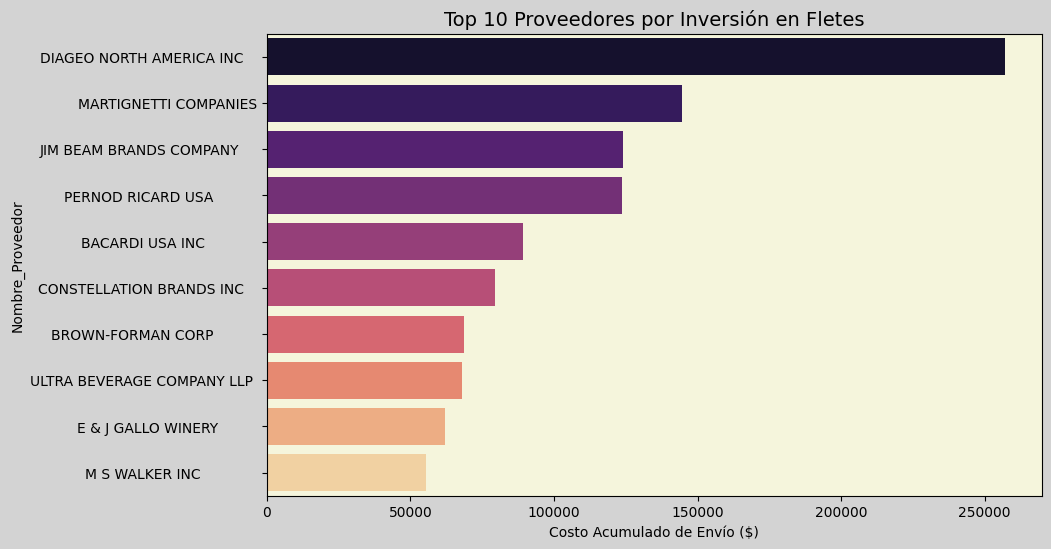

C:\Users\Usuario\AppData\Local\Temp\ipykernel_1936\3743945646.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=picos_demanda.values, y=picos_demanda.index.astype(str), palette='coolwarm')


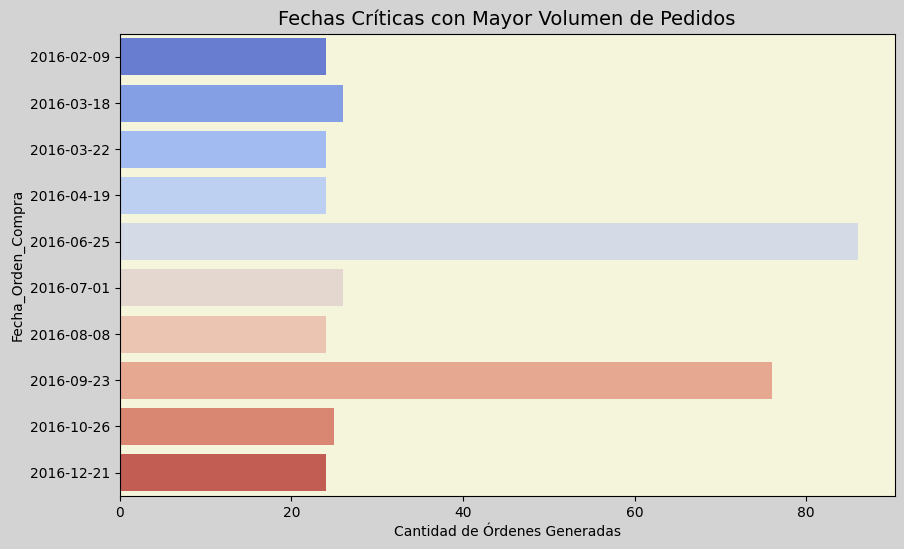

In [17]:
# 1. Concentración por frecuencia de facturación
frecuencia_proveedores = df_facturas['Nombre_Proveedor'].value_counts().head(10)

# 2. Cronología de demanda (Fechas pico)
picos_demanda = df_facturas['Fecha_Orden_Compra'].value_counts().head(10).sort_index()

# 3. Impacto financiero del transporte por proveedor
gasto_logistico_top = df_facturas.groupby('Nombre_Proveedor')['Costo_Envio'].sum().nlargest(10)

# --- Visualización 1: Costos de Envío ---
plt.figure(figsize=(10,6), facecolor='lightgray')
sns.barplot(x=gasto_logistico_top.values, y=gasto_logistico_top.index, palette='magma')
plt.gca().set_facecolor('beige')
plt.title('Top 10 Proveedores por Inversión en Fletes', fontsize=14)
plt.xlabel('Costo Acumulado de Envío ($)')
plt.show()

# --- Visualización 2: Volumen Temporal ---
plt.figure(figsize=(10,6), facecolor='lightgray')
sns.barplot(x=picos_demanda.values, y=picos_demanda.index.astype(str), palette='coolwarm')
plt.gca().set_facecolor('beige')
plt.title('Fechas Críticas con Mayor Volumen de Pedidos', fontsize=14)
plt.xlabel('Cantidad de Órdenes Generadas')
plt.show()

Paso 16: Exportación Final de Facturación Saneada
- Descripción: "Concluimos el proceso guardando la tabla de facturas con todas las transformaciones, renombrados y nuevas etiquetas de aprobación. Aplicamos la nomenclatura estándar definida para el proyecto."

In [18]:
# Definición de ruta y nombre de salida final
ruta_final_facturas = "../data/DatosProcesados/Compras_Limpias_Final.csv"

# Persistencia en formato CSV
df_facturas.to_csv(ruta_final_facturas, index=False)

print(f"Proceso finalizado. El archivo '{ruta_final_facturas}' ha sido generado con éxito.")

Proceso finalizado. El archivo '../data/DatosProcesados/Compras_Limpias_Final.csv' ha sido generado con éxito.


Paso 17: Transformación a Modelo Dimensional (Split de Tablas)
- Descripción: "Segmentamos el set de datos procesado para separar los atributos descriptivos de las métricas transaccionales. Este proceso genera las tablas de dimensiones y la tabla de hechos necesarias para implementar el esquema estrella solicitado."

In [19]:
# --- GENERACIÓN DE DIMENSIONES ---

# 1. Dim_Proveedor: Extraemos los datos únicos del proveedor
dim_proveedor = df_facturas[['Proveedor_ID', 'Nombre_Proveedor']].drop_duplicates().reset_index(drop=True)

# 2. Dim_Calendario: Requisito para el análisis de series temporales
# Creamos un rango de fechas basado en el dataset
fechas_unicas = pd.to_datetime(df_facturas['Fecha_Compra']).unique()
df_fechas = pd.DataFrame({'Fecha': fechas_unicas})

dim_calendario = pd.DataFrame({
    'Fecha_ID': df_fechas['Fecha'].dt.strftime('%Y%m%d').astype(int),
    'Fecha': df_fechas['Fecha'],
    'Año': df_fechas['Fecha'].dt.year,
    'Mes': df_fechas['Fecha'].dt.month,
    'Trimestre': df_fechas['Fecha'].dt.quarter,
    'Semana': df_fechas['Fecha'].dt.isocalendar().week
}).drop_duplicates().sort_values('Fecha_ID').reset_index(drop=True)

Paso 18: Construcción de la Tabla de Hechos (Fact_Compras)
- Descripción: "Estructuramos la tabla de hechos transaccionales vinculando las llaves foráneas con las dimensiones creadas. Optimizamos los tipos de datos para asegurar un almacenamiento eficiente en SQL Server."

In [20]:
# Vinculación temporal para la Fact Table
df_facturas['Fecha_ID'] = pd.to_datetime(df_facturas['Fecha_Compra']).dt.strftime('%Y%m%d').astype(int)

# Selección de columnas para la Fact_Compras según el diagrama
fact_compras = df_facturas[[
    'Compra_ID',       # Primary Key
    'Fecha_ID',        # Foreign Key a Dim_Calendario
    'Proveedor_ID',    # Foreign Key a Dim_Proveedor
    'Cantidad',        # Métrica
    'Importe',         # Métrica
    'Costo_Envio'      # Métrica
]].reset_index(drop=True)

Paso 19: Exportación Final al Modelo Estrella
- Descripción: "Persistimos los datos en archivos independientes dentro de la carpeta de DatosIngesta. Estos archivos serán la fuente de ingesta directa para las tablas de SQL Server, garantizando la integridad referencial del modelo."

In [21]:
# Exportación de las piezas del DWH por separado
dim_proveedor.to_csv("../data/DatosIngesta/Dim_Proveedor.csv", index=False)
dim_calendario.to_csv("../data/DatosIngesta/Dim_Calendario.csv", index=False)
fact_compras.to_csv("../data/DatosIngesta/Fact_Compras.csv", index=False)

print("Pipeline de exportación completado: Tablas Dim y Fact generadas.")

Pipeline de exportación completado: Tablas Dim y Fact generadas.
